In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.vq import kmeans
%matplotlib inline

In [2]:
df = pd.read_csv("26-customer_data.csv")

In [3]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.5 KB


<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

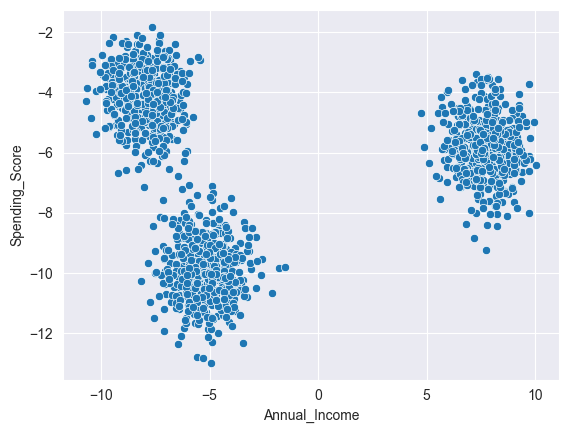

In [5]:
sns.scatterplot(data=df,x="Annual_Income",y="Spending_Score")

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test = train_test_split(df,test_size=0.2,random_state=15)

In [8]:
X_train

,Annual_Income,Spending_Score
258,7.809992,-5.031123
195,7.769519,-6.059915
817,-8.529586,-4.853877
820,-5.765759,-9.822013
716,-7.932068,-4.882406
...,...,...
667,-6.734875,-5.107626
156,-8.236823,-3.127431
384,-7.744180,-3.563590
645,-6.151325,-9.263209


In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [16]:
#elbow method
#kaç sınıf olmalı bu hesapla öğreniyoruz. kırılma yeri bizim kaç sınıf olacağımızı belirliyor.
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++' )
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [17]:
wcss

[196.9206878471016,
 68.44836482219306,
 11.697030239519933,
 9.89522895367582,
 8.100531938708878,
 6.088618494377364,
 5.615986074092099,
 4.995993643369122,
 4.614969472369286,
 4.025410090350798]

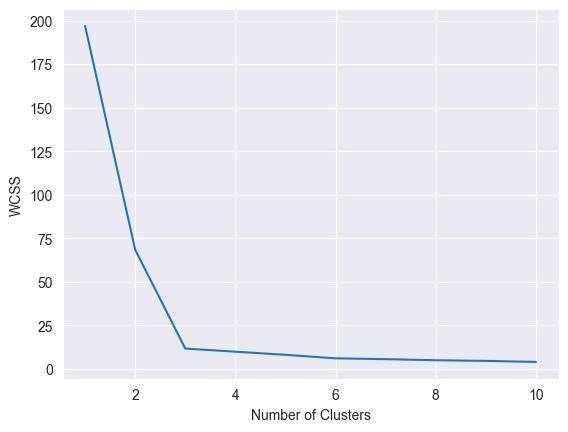

In [18]:
plt.plot(range(1,11),wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=3,init='k-means++' )
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
y_pred = kmeans.predict(X_test_scaled)

<Axes: xlabel='Annual_Income', ylabel='Spending_Score'>

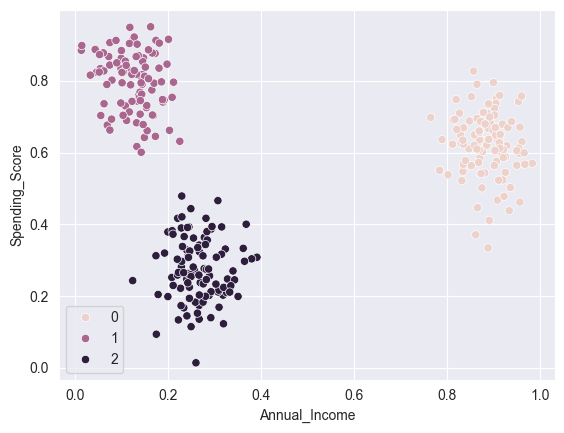

In [21]:
sns.scatterplot(pd.DataFrame(X_test_scaled, columns=X_test.columns,),x="Annual_Income",y="Spending_Score",hue=y_pred)

In [22]:
!pip install kneed

In [23]:
from kneed import KneeLocator

In [25]:
kl = KneeLocator(range(1,11),wcss,y_pred,curve='convex',direction='decreasing')

In [26]:
kl.elbow
#burada grafik olmadan kırılma noktası kaçıncı seviyede görmek için kullanılabilir.

np.int64(3)

In [28]:
#silhoutte score

In [29]:
from sklearn.metrics import silhouette_score

In [32]:
silhoutte_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init='k-means++' )
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhoutte_scores.append(score)

In [33]:
silhoutte_scores

[0.6538372460771634,
 0.7856941696336582,
 0.6543264512565816,
 0.5107434055544942,
 0.3942851120007156,
 0.37762634335697204,
 0.3735750260884111,
 0.3454580544615948,
 0.34164842658319]

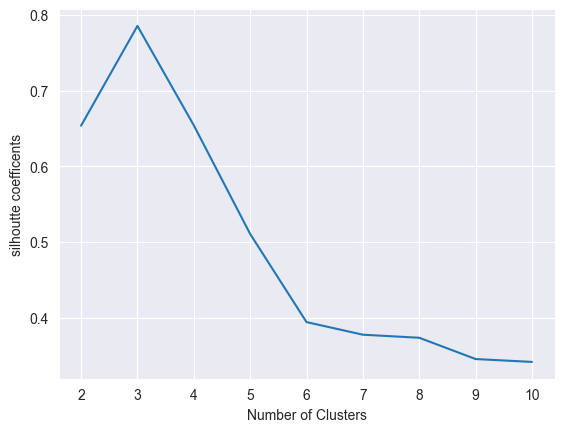

In [34]:
plt.plot(range(2,11),silhoutte_scores)
plt.xlabel('Number of Clusters')
plt.ylabel('silhoutte coefficents')
plt.show()